# Model-2 : Patch-Based Training

## Block 0. Import Libraries

This block imports all required packages for patch-based training.


In [1]:
# Block 2: Import all libraries used in this notebook and set random seeds.
import copy
import random
from pathlib import Path

import kagglehub
import matplotlib.pyplot as plt
import nibabel as nib
import numpy as np
import pandas as pd
import torch
import torch.nn as nn
import torch.nn.functional as F
from scipy.ndimage import binary_erosion, distance_transform_edt, rotate, shift as ndi_shift, zoom
from torch.utils.data import Dataset, DataLoader
from tqdm import tqdm

SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)

DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

# CUDA memory is automatic in PyTorch. We only select the device here.
if DEVICE.type == 'cuda':
    torch.backends.cudnn.benchmark = True
    print('Using device:', torch.cuda.get_device_name(0))
    print('CUDA memory mode: automatic PyTorch allocation')
else:
    print('Using device:', DEVICE)

/home/danishzaheer/miniconda3/envs/foundation_AI/lib/python3.11/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Using device: NVIDIA GeForce RTX 3060 Laptop GPU
CUDA memory mode: automatic PyTorch allocation


## Block 1. Configuration


In [2]:
# Block 1: Configuration.
SEED = 42

MODALITIES = ["flair", "t1", "t1ce", "t2"]
REGION_NAMES = ["WT", "TC", "ET"]
INPUT_CHANNELS = len(MODALITIES)
OUTPUT_CHANNELS = len(REGION_NAMES)

TRAIN_RATIO = 0.70
VALID_RATIO = 0.15
TEST_RATIO = 0.15

# Patch size is D, H, W because PyTorch 3D input is C, D, H, W.
PATCH_SIZE = (128, 128, 128)
# Smaller compressed cache target: about 5-10 GB depending on compression.
PATCHES_PER_TRAIN_CASE = 2
PATCHES_PER_EVAL_CASE = 1

BATCH_SIZE = 4  # increase to 4 on RTX 3090 if memory allows
NUM_EPOCHS = 40
LEARNING_RATE = 1e-3
WEIGHT_DECAY = 3e-4
LR_PATIENCE = 2
LR_FACTOR = 0.70
MIN_LR = 1e-5

# Patch model focuses more on TC and ET because WT is already strong.
DICE_REGION_WEIGHTS = {
    "WT": 0.05,
    "TC": 0.20,
    "ET": 0.75,
}
DICE_CLASS_WEIGHTS = [DICE_REGION_WEIGHTS[region_name] for region_name in REGION_NAMES]

DICE_LOSS_WEIGHT = 0.70
FOCAL_LOSS_WEIGHT = 0.30
FOCAL_ALPHA = 0.25
FOCAL_GAMMA = 2.0

BASE_CHANNELS = 16
DROPOUT_RATE = 0.15
NUM_WORKERS = 2
PREDICTION_THRESHOLD = 0.50
THRESHOLD_SEARCH_VALUES = np.round(np.arange(0.30, 0.81, 0.05), 2)
REGION_THRESHOLDS = {region_name: PREDICTION_THRESHOLD for region_name in REGION_NAMES}

# Compressed patch cache is mandatory and much smaller than caching full-resolution volumes.
PATCH_CACHE_IMAGE_DTYPE = np.float16
PATCH_CACHE_IMAGE_DTYPE_NAME = "float16"

# Patch sampling probabilities for training.
ET_PATCH_PROB = 0.50
TC_PATCH_PROB = 0.30
WT_PATCH_PROB = 0.10
RANDOM_PATCH_PROB = 0.10

# Simple patch augmentation.
USE_AUGMENTATION = True
FLIP_HEIGHT_PROB = 0.50
FLIP_WIDTH_PROB = 0.50
INTENSITY_PROB = 0.70
INTENSITY_SCALE_RANGE = (0.80, 1.20)
INTENSITY_SHIFT_RANGE = (-0.12, 0.12)
NOISE_PROB = 0.40
NOISE_STD = 0.04

# Keep as None to use all cases.
MAX_TRAIN_CASES = None
MAX_VALID_CASES = None
MAX_TEST_CASES = None


## Block 2. Reproducibility and paths


In [3]:
# Block 2: Reproducibility and paths.
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
if DEVICE.type == "cuda":
    torch.cuda.manual_seed_all(SEED)
    torch.backends.cudnn.benchmark = True


def find_project_root(start_path):
    start_path = Path(start_path).resolve()

    for folder in [start_path] + list(start_path.parents):
        if (folder / "data").exists():
            return folder

    return start_path


PROJECT_ROOT = find_project_root(Path.cwd())
DATA_ROOT = PROJECT_ROOT / "data"
PROCESSED_ROOT = DATA_ROOT / "processed"
CHECKPOINT_ROOT = PROJECT_ROOT / "checkpoints"

training_root_candidates = [
    DATA_ROOT / "brats2020" / "BraTS2020_TrainingData" / "MICCAI_BraTS2020_TrainingData",
    DATA_ROOT / "raw" / "BraTS2020_TrainingData" / "MICCAI_BraTS2020_TrainingData",
]

TRAINING_ROOT = None
for candidate in training_root_candidates:
    if candidate.exists():
        TRAINING_ROOT = candidate.resolve()
        break

if TRAINING_ROOT is None:
    raise FileNotFoundError("Could not find BraTS2020 training data in data/brats2020 or data/raw.")

CACHE_ROOT = PROCESSED_ROOT / f"paper3_cached_patches_{PATCH_SIZE[0]}_{PATCH_SIZE[1]}_{PATCH_SIZE[2]}_{PATCH_CACHE_IMAGE_DTYPE_NAME}_train{PATCHES_PER_TRAIN_CASE}_eval{PATCHES_PER_EVAL_CASE}_no_train_eval"
CHECKPOINT_ROOT.mkdir(parents=True, exist_ok=True)
CACHE_ROOT.mkdir(parents=True, exist_ok=True)

checkpoint_path = CHECKPOINT_ROOT / "paper3_air_unet_patch_latest.pt"
best_checkpoint_path = CHECKPOINT_ROOT / "paper3_air_unet_patch_best.pt"

print("Project root:", PROJECT_ROOT)
print("Training data:", TRAINING_ROOT)
print("Compressed patch cache:", CACHE_ROOT)
print("Checkpoints:", CHECKPOINT_ROOT)
print("Device:", DEVICE)
print("Patch size:", PATCH_SIZE)
print("Patch model Dice weights:", DICE_REGION_WEIGHTS)

Project root: /home/danishzaheer/Deep_learning_project
Training data: /home/danishzaheer/Deep_learning_project/data/raw/BraTS2020_TrainingData/MICCAI_BraTS2020_TrainingData
Compressed patch cache: /home/danishzaheer/Deep_learning_project/data/processed/paper3_cached_patches_128_128_128_float16_train2_eval1_no_train_eval
Checkpoints: /home/danishzaheer/Deep_learning_project/checkpoints
Device: cuda
Patch size: (128, 128, 128)
Patch model Dice weights: {'WT': 0.05, 'TC': 0.2, 'ET': 0.75}


## Block 3. Build train/valid/test dataframe


In [4]:
# Block 3: Build train/valid/test dataframe.
def get_case_paths(case_folder):
    case_id = case_folder.name
    paths = {"case_id": case_id, "case_folder": str(case_folder)}

    for modality in MODALITIES:
        matches = list(case_folder.glob(f"*_{modality}.nii*"))
        if not matches:
            return None
        paths[f"{modality}_path"] = str(matches[0])

    seg_matches = list(case_folder.glob("*_seg.nii*"))
    if not seg_matches:
        return None

    paths["seg_path"] = str(seg_matches[0])
    return paths


case_rows = []
for case_folder in sorted(TRAINING_ROOT.iterdir()):
    if case_folder.is_dir():
        row = get_case_paths(case_folder)
        if row is not None:
            case_rows.append(row)

cases_df = pd.DataFrame(case_rows)
if cases_df.empty:
    raise RuntimeError("No valid BraTS cases found.")

rng = np.random.default_rng(SEED)
case_ids = cases_df["case_id"].to_numpy()
rng.shuffle(case_ids)

num_cases = len(case_ids)
num_train = int(round(TRAIN_RATIO * num_cases))
num_valid = int(round(VALID_RATIO * num_cases))

train_ids = set(case_ids[:num_train])
valid_ids = set(case_ids[num_train : num_train + num_valid])
test_ids = set(case_ids[num_train + num_valid :])


def split_for_case(case_id):
    if case_id in train_ids:
        return "train"
    if case_id in valid_ids:
        return "valid"
    return "test"


cases_df["split"] = cases_df["case_id"].apply(split_for_case)

train_df = cases_df[cases_df["split"] == "train"].reset_index(drop=True)
valid_df = cases_df[cases_df["split"] == "valid"].reset_index(drop=True)
test_df = cases_df[cases_df["split"] == "test"].reset_index(drop=True)

if MAX_TRAIN_CASES is not None:
    train_df = train_df.head(MAX_TRAIN_CASES).reset_index(drop=True)
if MAX_VALID_CASES is not None:
    valid_df = valid_df.head(MAX_VALID_CASES).reset_index(drop=True)
if MAX_TEST_CASES is not None:
    test_df = test_df.head(MAX_TEST_CASES).reset_index(drop=True)

print("Train cases:", len(train_df))
print("Validation cases:", len(valid_df))
print("Test cases:", len(test_df))


Train cases: 258
Validation cases: 55
Test cases: 55


## Block 4. Load and Normalize Raw Volumes


In [5]:
# Block 4: Load and normalize raw BraTS volumes.
def normalize_volume(volume):
    volume = volume.astype(np.float32)
    brain_pixels = volume > 0

    if brain_pixels.sum() == 0:
        return volume

    mean_value = volume[brain_pixels].mean()
    std_value = volume[brain_pixels].std()
    volume[brain_pixels] = (volume[brain_pixels] - mean_value) / (std_value + 1e-8)
    return volume


def create_region_masks(segmentation):
    wt = np.isin(segmentation, [1, 2, 4]).astype(np.float32)
    tc = np.isin(segmentation, [1, 4]).astype(np.float32)
    et = (segmentation == 4).astype(np.float32)
    return np.stack([wt, tc, et], axis=0)


def load_case(row):
    image_channels = []

    for modality in MODALITIES:
        volume = np.asanyarray(nib.load(row[f"{modality}_path"]).dataobj).astype(np.float32)
        image_channels.append(normalize_volume(volume))

    segmentation = np.asanyarray(nib.load(row["seg_path"]).dataobj).astype(np.int16)
    mask = create_region_masks(segmentation)

    # Original data is H, W, D. PyTorch 3D expects C, D, H, W.
    image = np.stack(image_channels, axis=0).astype(np.float32)
    image = np.transpose(image, (0, 3, 1, 2))
    mask = np.transpose(mask, (0, 3, 1, 2))
    return image, mask


## Block 5. Compressed Patch Cache and DataLoaders


In [6]:
# Block 5: Extract, compress, cache, and load tumor-focused patches.
def crop_or_pad_patch(volume, center, patch_size):
    # volume shape: C, D, H, W
    channels = volume.shape[0]
    patch = np.zeros((channels, *patch_size), dtype=volume.dtype)

    source_slices = [slice(0, channels)]
    target_slices = [slice(0, channels)]

    for center_value, patch_dim, volume_dim in zip(center, patch_size, volume.shape[1:]):
        start = int(center_value) - patch_dim // 2
        end = start + patch_dim

        source_start = max(start, 0)
        source_end = min(end, volume_dim)

        target_start = max(0, -start)
        target_end = target_start + (source_end - source_start)

        source_slices.append(slice(source_start, source_end))
        target_slices.append(slice(target_start, target_end))

    patch[tuple(target_slices)] = volume[tuple(source_slices)]
    return patch


def choose_center_from_mask(mask_3d, rng):
    coordinates = np.argwhere(mask_3d > 0)

    if len(coordinates) == 0:
        return None

    return tuple(coordinates[rng.integers(0, len(coordinates))])


def choose_random_brain_center(image, rng):
    brain_mask = np.any(image != 0, axis=0)
    center = choose_center_from_mask(brain_mask, rng)

    if center is not None:
        return center

    return tuple(size // 2 for size in image.shape[1:])


def choose_patch_center(image, mask, rng, training=True):
    wt_index = REGION_NAMES.index("WT")
    tc_index = REGION_NAMES.index("TC")
    et_index = REGION_NAMES.index("ET")

    if training:
        sample_value = rng.random()

        if sample_value < ET_PATCH_PROB:
            center = choose_center_from_mask(mask[et_index], rng)
            if center is not None:
                return center

        if sample_value < ET_PATCH_PROB + TC_PATCH_PROB:
            center = choose_center_from_mask(mask[tc_index], rng)
            if center is not None:
                return center

        if sample_value < ET_PATCH_PROB + TC_PATCH_PROB + WT_PATCH_PROB:
            center = choose_center_from_mask(mask[wt_index], rng)
            if center is not None:
                return center

        return choose_random_brain_center(image, rng)

    # Validation/test patches are deterministic and tumor-focused for monitoring.
    for region_index in [et_index, tc_index, wt_index]:
        center = choose_center_from_mask(mask[region_index], rng)
        if center is not None:
            return center

    return choose_random_brain_center(image, rng)


def patch_cache_folder(split_label, case_id):
    return CACHE_ROOT / split_label / case_id


def patch_cache_file(split_label, case_id, patch_index):
    return patch_cache_folder(split_label, case_id) / f"patch_{patch_index:03d}.npz"


def patch_rng(split_label, case_index, patch_index):
    split_offset = {"train": 1000, "valid": 2000, "test": 3000}[split_label]
    return np.random.default_rng(SEED + split_offset + case_index * 1009 + patch_index)


def save_patch_to_cache(image, mask, center, patch_path):
    image_patch = crop_or_pad_patch(image, center, PATCH_SIZE).astype(PATCH_CACHE_IMAGE_DTYPE)
    mask_patch = crop_or_pad_patch(mask, center, PATCH_SIZE).astype(np.uint8)
    center_array = np.array(center, dtype=np.int16)

    patch_path.parent.mkdir(parents=True, exist_ok=True)
    temporary_path = patch_path.with_suffix(".tmp.npz")

    # Compressed .npz + float16 image + uint8 mask is much smaller than full-volume float32 caching.
    np.savez_compressed(temporary_path, image=image_patch, mask=mask_patch, center=center_array)
    temporary_path.replace(patch_path)


def save_case_patches_to_cache(row, split_label, case_index, patches_per_case, training_sampling):
    missing_patch_indices = []

    for patch_index in range(patches_per_case):
        patch_path = patch_cache_file(split_label, row["case_id"], patch_index)
        if not patch_path.exists():
            missing_patch_indices.append(patch_index)

    if len(missing_patch_indices) == 0:
        return

    image, mask = load_case(row)

    for patch_index in missing_patch_indices:
        rng = patch_rng(split_label, case_index, patch_index)
        center = choose_patch_center(image, mask, rng, training=training_sampling)
        patch_path = patch_cache_file(split_label, row["case_id"], patch_index)
        save_patch_to_cache(image, mask, center, patch_path)


def prepare_patch_cache_split(dataframe, split_label, patches_per_case, training_sampling):
    for case_index, row in tqdm(
        dataframe.iterrows(),
        total=len(dataframe),
        desc=f"Caching compressed {split_label} patches",
    ):
        save_case_patches_to_cache(row, split_label, case_index, patches_per_case, training_sampling)

    print(f"{split_label} cached patches:", len(dataframe) * patches_per_case)


prepare_patch_cache_split(train_df, "train", PATCHES_PER_TRAIN_CASE, training_sampling=True)
prepare_patch_cache_split(valid_df, "valid", PATCHES_PER_EVAL_CASE, training_sampling=False)
prepare_patch_cache_split(test_df, "test", PATCHES_PER_EVAL_CASE, training_sampling=False)


def apply_patch_augmentation(image, mask):
    if not USE_AUGMENTATION:
        return image, mask

    if random.random() < FLIP_HEIGHT_PROB:
        image = np.flip(image, axis=2).copy()
        mask = np.flip(mask, axis=2).copy()

    if random.random() < FLIP_WIDTH_PROB:
        image = np.flip(image, axis=3).copy()
        mask = np.flip(mask, axis=3).copy()

    brain_mask = np.any(image != 0, axis=0, keepdims=True).astype(np.float32)

    if random.random() < INTENSITY_PROB:
        scale = random.uniform(*INTENSITY_SCALE_RANGE)
        shift = random.uniform(*INTENSITY_SHIFT_RANGE)
        image = image * scale + shift * brain_mask

    if random.random() < NOISE_PROB:
        noise = np.random.normal(0, NOISE_STD, size=image.shape).astype(np.float32)
        image = image + noise * brain_mask

    return image.astype(np.float32), mask.astype(np.float32)


class BraTSCachedPatchDataset(Dataset):
    def __init__(self, dataframe, split_label, cache_split_label, patches_per_case, training=False):
        self.dataframe = dataframe.reset_index(drop=True)
        self.split_label = split_label
        self.cache_split_label = cache_split_label
        self.patches_per_case = patches_per_case
        self.training = training

    def __len__(self):
        return len(self.dataframe) * self.patches_per_case

    def __getitem__(self, index):
        case_index = index // self.patches_per_case
        patch_index = index % self.patches_per_case
        row = self.dataframe.iloc[case_index]

        patch_path = patch_cache_file(self.cache_split_label, row["case_id"], patch_index)

        with np.load(patch_path) as patch_data:
            image_patch = patch_data["image"].astype(np.float32)
            mask_patch = patch_data["mask"].astype(np.float32)

        if self.training:
            image_patch, mask_patch = apply_patch_augmentation(image_patch, mask_patch)

        return torch.from_numpy(image_patch.copy()), torch.from_numpy(mask_patch.copy())


train_dataset = BraTSCachedPatchDataset(train_df, "train", "train", PATCHES_PER_TRAIN_CASE, training=True)
train_analysis_dataset = BraTSCachedPatchDataset(train_df, "train", "train", PATCHES_PER_TRAIN_CASE, training=False)
valid_dataset = BraTSCachedPatchDataset(valid_df, "valid", "valid", PATCHES_PER_EVAL_CASE, training=False)
test_dataset = BraTSCachedPatchDataset(test_df, "test", "test", PATCHES_PER_EVAL_CASE, training=False)

pin_memory = DEVICE.type == "cuda"
loader_kwargs = {
    "num_workers": NUM_WORKERS,
    "pin_memory": pin_memory,
}

if NUM_WORKERS > 0:
    loader_kwargs["persistent_workers"] = True
    loader_kwargs["prefetch_factor"] = 2

train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True, **loader_kwargs)
train_analysis_loader = DataLoader(train_analysis_dataset, batch_size=BATCH_SIZE, shuffle=False, **loader_kwargs)
valid_loader = DataLoader(valid_dataset, batch_size=BATCH_SIZE, shuffle=False, **loader_kwargs)
test_loader = DataLoader(test_dataset, batch_size=BATCH_SIZE, shuffle=False, **loader_kwargs)

print("Train patches per epoch:", len(train_dataset))
print("Train analysis patches:", len(train_analysis_dataset))
print("Validation patches:", len(valid_dataset))
print("Test patches:", len(test_dataset))
print("Compressed patch cache folder:", CACHE_ROOT)


Caching compressed train patches:   0%|          | 0/258 [00:00<?, ?it/s]

Caching compressed train patches: 100%|██████████| 258/258 [08:00<00:00,  1.86s/it]


train cached patches: 516


Caching compressed valid patches: 100%|██████████| 55/55 [01:15<00:00,  1.37s/it]


valid cached patches: 55


Caching compressed test patches: 100%|██████████| 55/55 [01:15<00:00,  1.37s/it]

test cached patches: 55
Train patches per epoch: 516
Train analysis patches: 516
Validation patches: 55
Test patches: 55
Compressed patch cache folder: /home/danishzaheer/Deep_learning_project/data/processed/paper3_cached_patches_128_128_128_float16_train2_eval1_no_train_eval


## Block 6. Loss


In [7]:
# Block 6: Loss.
class SoftDiceLoss(nn.Module):
    def __init__(self, class_weights=None, smooth=1e-6):
        super().__init__()
        self.smooth = smooth

        if class_weights is None:
            class_weights = [1.0, 1.0, 1.0]

        class_weights = torch.tensor(class_weights, dtype=torch.float32)
        class_weights = class_weights / class_weights.sum()
        self.register_buffer("class_weights", class_weights)

    def forward(self, logits, targets):
        probabilities = torch.sigmoid(logits)
        probabilities = probabilities.reshape(probabilities.size(0), probabilities.size(1), -1)
        targets_flat = targets.reshape(targets.size(0), targets.size(1), -1)

        intersection = (probabilities * targets_flat).sum(dim=2)
        denominator = (probabilities**2).sum(dim=2) + (targets_flat**2).sum(dim=2)
        dice_score = (2 * intersection + self.smooth) / (denominator + self.smooth)
        dice_loss = 1 - dice_score
        return (dice_loss.mean(dim=0) * self.class_weights).sum()


class FocalBCELoss(nn.Module):
    def __init__(self, class_weights=None, alpha=0.25, gamma=2.0):
        super().__init__()
        self.alpha = alpha
        self.gamma = gamma

        if class_weights is None:
            class_weights = [1.0, 1.0, 1.0]

        class_weights = torch.tensor(class_weights, dtype=torch.float32)
        class_weights = class_weights / class_weights.sum()
        self.register_buffer("class_weights", class_weights)

    def forward(self, logits, targets):
        bce_loss = F.binary_cross_entropy_with_logits(logits, targets, reduction="none")
        probabilities = torch.sigmoid(logits)
        p_t = probabilities * targets + (1 - probabilities) * (1 - targets)
        alpha_t = self.alpha * targets + (1 - self.alpha) * (1 - targets)
        focal_loss = alpha_t * ((1 - p_t) ** self.gamma) * bce_loss

        focal_loss = focal_loss.reshape(focal_loss.size(0), focal_loss.size(1), -1)
        focal_loss = focal_loss.mean(dim=2)
        return (focal_loss.mean(dim=0) * self.class_weights).sum()


class DiceFocalLoss(nn.Module):
    def __init__(self, class_weights=None):
        super().__init__()
        self.dice_loss = SoftDiceLoss(class_weights=class_weights)
        self.focal_loss = FocalBCELoss(
            class_weights=class_weights,
            alpha=FOCAL_ALPHA,
            gamma=FOCAL_GAMMA,
        )

    def forward(self, logits, targets):
        dice = self.dice_loss(logits, targets)
        focal = self.focal_loss(logits, targets)
        return DICE_LOSS_WEIGHT * dice + FOCAL_LOSS_WEIGHT * focal


## Block 7. Model


In [8]:
# Block 7: Model.
class InceptionResidualBlock3D(nn.Module):
    def __init__(self, in_channels, out_channels):
        super().__init__()
        branch_channels = out_channels // 4

        self.branch1 = nn.Sequential(
            nn.Conv3d(in_channels, branch_channels, kernel_size=1, bias=False),
            nn.BatchNorm3d(branch_channels),
            nn.ReLU(inplace=True),
        )

        self.branch3 = nn.Sequential(
            nn.Conv3d(in_channels, branch_channels, kernel_size=1, bias=False),
            nn.BatchNorm3d(branch_channels),
            nn.ReLU(inplace=True),
            nn.Conv3d(branch_channels, branch_channels, kernel_size=3, padding=1, bias=False),
            nn.BatchNorm3d(branch_channels),
            nn.ReLU(inplace=True),
        )

        self.branch5 = nn.Sequential(
            nn.Conv3d(in_channels, branch_channels, kernel_size=1, bias=False),
            nn.BatchNorm3d(branch_channels),
            nn.ReLU(inplace=True),
            nn.Conv3d(branch_channels, branch_channels, kernel_size=5, padding=2, bias=False),
            nn.BatchNorm3d(branch_channels),
            nn.ReLU(inplace=True),
        )

        self.branch_pool = nn.Sequential(
            nn.MaxPool3d(kernel_size=3, stride=1, padding=1),
            nn.Conv3d(in_channels, branch_channels, kernel_size=1, bias=False),
            nn.BatchNorm3d(branch_channels),
            nn.ReLU(inplace=True),
        )

        self.fuse = nn.Sequential(
            nn.Conv3d(out_channels, out_channels, kernel_size=1, bias=False),
            nn.BatchNorm3d(out_channels),
        )

        self.shortcut = nn.Identity()
        if in_channels != out_channels:
            self.shortcut = nn.Conv3d(in_channels, out_channels, kernel_size=1, bias=False)

        self.relu = nn.ReLU(inplace=True)

    def forward(self, x):
        b1 = self.branch1(x)
        b3 = self.branch3(x)
        b5 = self.branch5(x)
        bp = self.branch_pool(x)
        combined = torch.cat([b1, b3, b5, bp], dim=1)
        combined = self.fuse(combined)
        return self.relu(combined + self.shortcut(x))


class AttentionGate3D(nn.Module):
    def __init__(self, gate_channels, skip_channels, mid_channels):
        super().__init__()
        self.gate_conv = nn.Conv3d(gate_channels, mid_channels, kernel_size=1, bias=False)
        self.skip_conv = nn.Conv3d(skip_channels, mid_channels, kernel_size=1, bias=False)
        self.psi = nn.Sequential(
            nn.ReLU(inplace=True),
            nn.Conv3d(mid_channels, 1, kernel_size=1),
            nn.Sigmoid(),
        )

    def forward(self, gate, skip):
        gate_features = self.gate_conv(gate)
        skip_features = self.skip_conv(skip)

        if gate_features.shape[-3:] != skip_features.shape[-3:]:
            gate_features = F.interpolate(gate_features, size=skip_features.shape[-3:], mode="trilinear", align_corners=False)

        attention = self.psi(gate_features + skip_features)
        return skip * attention


class DecoderBlock3D(nn.Module):
    def __init__(self, in_channels, skip_channels, out_channels):
        super().__init__()
        self.up = nn.ConvTranspose3d(in_channels, out_channels, kernel_size=2, stride=2)
        self.attention = AttentionGate3D(out_channels, skip_channels, out_channels // 2)
        self.block = InceptionResidualBlock3D(out_channels + skip_channels, out_channels)

    def forward(self, x, skip):
        x = self.up(x)

        if x.shape[-3:] != skip.shape[-3:]:
            x = F.interpolate(x, size=skip.shape[-3:], mode="trilinear", align_corners=False)

        skip = self.attention(x, skip)
        x = torch.cat([skip, x], dim=1)
        return self.block(x)


class PlainDecoderBlock3D(nn.Module):
    def __init__(self, in_channels, skip_channels, out_channels):
        super().__init__()
        self.up = nn.ConvTranspose3d(in_channels, out_channels, kernel_size=2, stride=2)
        self.block = InceptionResidualBlock3D(out_channels + skip_channels, out_channels)

    def forward(self, x, skip):
        x = self.up(x)

        if x.shape[-3:] != skip.shape[-3:]:
            x = F.interpolate(x, size=skip.shape[-3:], mode="trilinear", align_corners=False)

        x = torch.cat([skip, x], dim=1)
        return self.block(x)


class AIRUNet3D(nn.Module):
    def __init__(self, input_channels=4, output_channels=3, base_channels=16):
        super().__init__()
        self.pool = nn.MaxPool3d(2)
        self.dropout = nn.Dropout3d(p=DROPOUT_RATE)

        self.enc1 = InceptionResidualBlock3D(input_channels, base_channels)
        self.enc2 = InceptionResidualBlock3D(base_channels, base_channels * 2)
        self.enc3 = InceptionResidualBlock3D(base_channels * 2, base_channels * 4)
        self.enc4 = InceptionResidualBlock3D(base_channels * 4, base_channels * 8)

        self.bottleneck = InceptionResidualBlock3D(base_channels * 8, base_channels * 16)

        self.dec4 = DecoderBlock3D(base_channels * 16, base_channels * 8, base_channels * 8)
        self.dec3 = DecoderBlock3D(base_channels * 8, base_channels * 4, base_channels * 4)
        self.dec2 = DecoderBlock3D(base_channels * 4, base_channels * 2, base_channels * 2)
        self.dec1 = PlainDecoderBlock3D(base_channels * 2, base_channels, base_channels)

        self.output = nn.Conv3d(base_channels, output_channels, kernel_size=1)

    def forward(self, x):
        x1 = self.enc1(x)
        x2 = self.enc2(self.pool(x1))
        x3 = self.enc3(self.pool(x2))
        x4 = self.dropout(self.enc4(self.pool(x3)))

        b = self.dropout(self.bottleneck(self.pool(x4)))

        d4 = self.dropout(self.dec4(b, x4))
        d3 = self.dropout(self.dec3(d4, x3))
        d2 = self.dec2(d3, x2)
        d1 = self.dec1(d2, x1)

        return self.output(d1)


def count_parameters(model):
    return sum(parameter.numel() for parameter in model.parameters() if parameter.requires_grad)


model = AIRUNet3D(INPUT_CHANNELS, OUTPUT_CHANNELS, base_channels=BASE_CHANNELS).to(DEVICE)
print("Trainable parameters:", f"{count_parameters(model):,}")


Trainable parameters: 1,693,046


## Block 8. Training helpers


In [9]:
# Block 8: Training helpers.
def move_batch_to_device(images, masks):
    non_blocking = DEVICE.type == "cuda"
    images = images.to(DEVICE, non_blocking=non_blocking)
    masks = masks.to(DEVICE, non_blocking=non_blocking)
    return images, masks


def apply_hierarchical_postprocessing(predictions):
    predictions = predictions.bool().clone()
    wt_index = REGION_NAMES.index("WT")
    tc_index = REGION_NAMES.index("TC")
    et_index = REGION_NAMES.index("ET")

    predictions[:, tc_index] = predictions[:, tc_index] & predictions[:, wt_index]
    predictions[:, et_index] = predictions[:, et_index] & predictions[:, tc_index]
    return predictions


def threshold_probabilities(probabilities, region_thresholds):
    prediction_channels = []

    for region_index, region_name in enumerate(REGION_NAMES):
        threshold = region_thresholds.get(region_name, PREDICTION_THRESHOLD)
        prediction_channels.append(probabilities[:, region_index] >= threshold)

    predictions = torch.stack(prediction_channels, dim=1)
    return apply_hierarchical_postprocessing(predictions)


def dice_per_region(logits, targets, threshold=0.5):
    probabilities = torch.sigmoid(logits)
    thresholds = {region_name: threshold for region_name in REGION_NAMES}
    predictions = threshold_probabilities(probabilities, thresholds).float()

    predictions = predictions.reshape(predictions.size(0), predictions.size(1), -1)
    targets = targets.reshape(targets.size(0), targets.size(1), -1)

    true_positive = (predictions * targets).sum(dim=2)
    false_positive = (predictions * (1 - targets)).sum(dim=2)
    false_negative = ((1 - predictions) * targets).sum(dim=2)
    dice = (2 * true_positive + 1e-6) / (2 * true_positive + false_positive + false_negative + 1e-6)
    return dice.mean(dim=0).detach().cpu().numpy()


def weighted_dice_score(region_dice):
    weights = np.array(DICE_CLASS_WEIGHTS, dtype=np.float64)
    region_dice = np.array(region_dice, dtype=np.float64)
    return float((region_dice * weights).sum())


def run_one_epoch(model, data_loader, criterion, optimizer=None):
    is_training = optimizer is not None
    model.train() if is_training else model.eval()

    total_loss = 0.0
    dice_sum = np.zeros(3, dtype=np.float64)
    batch_count = 0

    for images, masks in tqdm(data_loader, leave=False):
        images, masks = move_batch_to_device(images, masks)

        if is_training:
            optimizer.zero_grad(set_to_none=True)

        with torch.set_grad_enabled(is_training):
            logits = model(images)
            loss = criterion(logits, masks)

            if is_training:
                loss.backward()
                optimizer.step()

        total_loss += loss.item() * images.size(0)
        dice_sum += dice_per_region(logits, masks, threshold=PREDICTION_THRESHOLD)
        batch_count += 1

    average_loss = total_loss / len(data_loader.dataset)
    average_dice = dice_sum / max(batch_count, 1)
    return average_loss, average_dice


def make_history_row(epoch, train_loss, valid_loss, valid_dice):
    return {
        "epoch": epoch,
        "train_loss": train_loss,
        "valid_loss": valid_loss,
        "valid_weighted_dice": weighted_dice_score(valid_dice),
        "valid_WT_dice": valid_dice[0],
        "valid_TC_dice": valid_dice[1],
        "valid_ET_dice": valid_dice[2],
    }


## Block 9. Checkpointing and training


In [10]:
# Block 9: Checkpointing and training.
criterion = DiceFocalLoss(class_weights=DICE_CLASS_WEIGHTS).to(DEVICE)
optimizer = torch.optim.AdamW(model.parameters(), lr=LEARNING_RATE, weight_decay=WEIGHT_DECAY)


def save_checkpoint(epoch, best_valid_score, history, epochs_without_improvement, is_best=False):
    checkpoint = {
        "epoch": epoch,
        "model_state_dict": model.state_dict(),
        "optimizer_state_dict": optimizer.state_dict(),
        "best_valid_dice_score": best_valid_score,
        "monitor_metric": "valid_weighted_dice",
        "history": history,
        "epochs_without_improvement": epochs_without_improvement,
        "patch_size": PATCH_SIZE,
        "base_channels": BASE_CHANNELS,
        "dropout_rate": DROPOUT_RATE,
        "optimizer_name": "AdamW",
        "loss_name": "DiceFocalLoss",
        "dice_loss_weight": DICE_LOSS_WEIGHT,
        "focal_loss_weight": FOCAL_LOSS_WEIGHT,
        "focal_alpha": FOCAL_ALPHA,
        "focal_gamma": FOCAL_GAMMA,
        "dice_region_weights": DICE_REGION_WEIGHTS,
    }

    torch.save(checkpoint, checkpoint_path)

    if is_best:
        torch.save(checkpoint, best_checkpoint_path)


def load_checkpoint_if_available():
    if not checkpoint_path.exists():
        print("No previous patch checkpoint found. Starting from epoch 1.")
        return 1, -float("inf"), [], 0

    checkpoint = torch.load(checkpoint_path, map_location=DEVICE)
    model.load_state_dict(checkpoint["model_state_dict"])
    optimizer.load_state_dict(checkpoint["optimizer_state_dict"])

    start_epoch = checkpoint["epoch"] + 1
    best_valid_score = checkpoint["best_valid_dice_score"]
    history = checkpoint["history"]
    epochs_without_improvement = checkpoint.get("epochs_without_improvement", 0)

    print("Resumed from checkpoint:", checkpoint_path)
    print("Next epoch:", start_epoch)
    print("Best validation weighted Dice so far:", round(best_valid_score, 4))
    return start_epoch, best_valid_score, history, epochs_without_improvement


def reduce_learning_rate_if_needed(is_best, epochs_without_improvement):
    if is_best:
        return 0

    epochs_without_improvement += 1

    if epochs_without_improvement >= LR_PATIENCE:
        for param_group in optimizer.param_groups:
            param_group["lr"] = max(param_group["lr"] * LR_FACTOR, MIN_LR)

        print("Validation weighted Dice did not improve for", LR_PATIENCE, "epochs.")
        print("Reduced learning rate to:", optimizer.param_groups[0]["lr"])
        return 0

    return epochs_without_improvement


start_epoch, best_valid_score, history, epochs_without_improvement = load_checkpoint_if_available()

if start_epoch > NUM_EPOCHS:
    print("Checkpoint already reached NUM_EPOCHS. Increase NUM_EPOCHS if you want to continue training.")
else:
    for epoch in range(start_epoch, NUM_EPOCHS + 1):
        train_loss, train_dice = run_one_epoch(model, train_loader, criterion, optimizer=optimizer)
        valid_loss, valid_dice = run_one_epoch(model, valid_loader, criterion, optimizer=None)

        valid_score = weighted_dice_score(valid_dice)
        history.append(make_history_row(epoch, train_loss, valid_loss, valid_dice))

        is_best = valid_score > best_valid_score
        if is_best:
            best_valid_score = valid_score

        epochs_without_improvement = reduce_learning_rate_if_needed(is_best, epochs_without_improvement)
        save_checkpoint(epoch, best_valid_score, history, epochs_without_improvement, is_best=is_best)

        print(
            f"| Epoch {epoch}/{NUM_EPOCHS} |\n"
            f"| train loss {train_loss:.4f} | WT {train_dice[0]:.4f} TC {train_dice[1]:.4f} ET {train_dice[2]:.4f} |\n"
            f"| valid loss {valid_loss:.4f} | WT {valid_dice[0]:.4f} TC {valid_dice[1]:.4f} ET {valid_dice[2]:.4f} | "
            f"valid weighted Dice {valid_score:.4f} | lr {optimizer.param_groups[0]['lr']:.6f}"
        )
        print("Saved checkpoint:", checkpoint_path)


if best_checkpoint_path.exists():
    best_checkpoint = torch.load(best_checkpoint_path, map_location=DEVICE)
    model.load_state_dict(best_checkpoint["model_state_dict"])
    print("Loaded best patch checkpoint for evaluation:", best_checkpoint_path)

history_df = pd.DataFrame(history)
print(history_df.tail())


/tmp/ipykernel_32906/3672952257.py:38: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  checkpoint = torch.load(checkpoint_path, map_location=DEVICE)


Resumed from checkpoint: /home/danishzaheer/Deep_learning_project/checkpoints/paper3_air_unet_patch_latest.pt
Next epoch: 41
Best validation weighted Dice so far: 0.4891
Checkpoint already reached NUM_EPOCHS. Increase NUM_EPOCHS if you want to continue training.
Loaded best patch checkpoint for evaluation: /home/danishzaheer/Deep_learning_project/checkpoints/paper3_air_unet_patch_best.pt
    epoch  train_loss  valid_loss  valid_weighted_dice  valid_WT_dice  \
35     36    0.081624    0.390729             0.475706       0.805540   
36     37    0.081399    0.386661             0.480613       0.817734   
37     38    0.081277    0.391961             0.473923       0.810739   
38     39    0.081421    0.389766             0.476568       0.806467   
39     40    0.081665    0.392331             0.474112       0.815194   

    valid_TC_dice  valid_ET_dice  
35       0.437087       0.464016  
36       0.459841       0.463678  
37       0.423584       0.464893  
38       0.439648       0.4644

/tmp/ipykernel_32906/3672952257.py:99: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  best_checkpoint = torch.load(best_checkpoint_path, map_location=DEVICE)


## Block 10. Patch-level paper metrics


In [11]:
# Block 10: Patch-level paper metrics.
def update_binary_counts(counts, prediction, target):
    prediction = prediction.bool()
    target = target.bool()

    counts["tp"] += torch.logical_and(prediction, target).sum().item()
    counts["fp"] += torch.logical_and(prediction, ~target).sum().item()
    counts["tn"] += torch.logical_and(~prediction, ~target).sum().item()
    counts["fn"] += torch.logical_and(~prediction, target).sum().item()


def safe_divide(numerator, denominator):
    return numerator / denominator if denominator > 0 else 0.0


def calculate_paper_metrics_from_counts(region_name, counts, split_label):
    tp = counts["tp"]
    fp = counts["fp"]
    tn = counts["tn"]
    fn = counts["fn"]

    return {
        "split": split_label,
        "region": region_name,
        "dice": safe_divide(2 * tp, 2 * tp + fp + fn),
        "sensitivity": safe_divide(tp, tp + fn),
        "specificity": safe_divide(tn, tn + fp),
        "tp": tp,
        "fp": fp,
        "tn": tn,
        "fn": fn,
    }


def crop_to_foreground(prediction, target, margin=2):
    union = prediction | target

    if not union.any():
        return prediction, target

    crop_slices = []
    for axis_coordinates, axis_size in zip(np.where(union), union.shape):
        start = max(int(axis_coordinates.min()) - margin, 0)
        end = min(int(axis_coordinates.max()) + margin + 1, axis_size)
        crop_slices.append(slice(start, end))

    crop_slices = tuple(crop_slices)
    return prediction[crop_slices], target[crop_slices]


def get_surface(mask):
    if not mask.any():
        return mask

    eroded = binary_erosion(mask, structure=np.ones((3, 3, 3)), border_value=0)
    return mask ^ eroded


def calculate_hd95(prediction, target):
    prediction = prediction.astype(bool)
    target = target.astype(bool)

    if not prediction.any() and not target.any():
        return 0.0

    if not prediction.any() or not target.any():
        return float(np.linalg.norm(prediction.shape))

    prediction, target = crop_to_foreground(prediction, target)
    prediction_surface = get_surface(prediction)
    target_surface = get_surface(target)

    distance_to_target = distance_transform_edt(~target_surface)
    distance_to_prediction = distance_transform_edt(~prediction_surface)

    prediction_to_target = distance_to_target[prediction_surface]
    target_to_prediction = distance_to_prediction[target_surface]
    all_surface_distances = np.concatenate([prediction_to_target, target_to_prediction])
    return float(np.percentile(all_surface_distances, 95))


def tune_thresholds_on_validation(model, data_loader, threshold_values):
    model.eval()
    threshold_values = [float(value) for value in threshold_values]
    region_scores = {region: [] for region in REGION_NAMES}

    for threshold in threshold_values:
        thresholds = {region_name: threshold for region_name in REGION_NAMES}
        metric_counts = {region: {"tp": 0, "fp": 0, "tn": 0, "fn": 0} for region in REGION_NAMES}

        with torch.no_grad():
            for images, masks in tqdm(data_loader, leave=False, desc=f"Tuning threshold {threshold:.2f}"):
                images, masks = move_batch_to_device(images, masks)

                logits = model(images)
                probabilities = torch.sigmoid(logits)
                predictions = threshold_probabilities(probabilities, thresholds)
                targets = masks >= 0.5

                for region_index, region_name in enumerate(REGION_NAMES):
                    update_binary_counts(metric_counts[region_name], predictions[:, region_index], targets[:, region_index])

        for region_name in REGION_NAMES:
            counts = metric_counts[region_name]
            dice = safe_divide(2 * counts["tp"], 2 * counts["tp"] + counts["fp"] + counts["fn"])
            region_scores[region_name].append({"region": region_name, "threshold": threshold, "valid_dice": dice})

    threshold_rows = []
    best_thresholds = {}

    for region_name in REGION_NAMES:
        rows = region_scores[region_name]
        best_row = max(rows, key=lambda row: row["valid_dice"])
        best_thresholds[region_name] = best_row["threshold"]
        threshold_rows.extend(rows)

    return best_thresholds, pd.DataFrame(threshold_rows)


def calculate_paper_metrics_for_loader(model, data_loader, split_label, region_thresholds):
    model.eval()
    metric_counts = {region: {"tp": 0, "fp": 0, "tn": 0, "fn": 0} for region in REGION_NAMES}
    hd95_values = {region: [] for region in REGION_NAMES}

    with torch.no_grad():
        for images, masks in tqdm(data_loader, leave=False, desc=f"Metrics {split_label}"):
            images, masks = move_batch_to_device(images, masks)

            logits = model(images)
            probabilities = torch.sigmoid(logits)
            predictions = threshold_probabilities(probabilities, region_thresholds)
            targets = masks >= 0.5

            for region_index, region_name in enumerate(REGION_NAMES):
                region_predictions = predictions[:, region_index]
                region_targets = targets[:, region_index]

                update_binary_counts(metric_counts[region_name], region_predictions, region_targets)

                predictions_np = region_predictions.detach().cpu().numpy()
                targets_np = region_targets.detach().cpu().numpy()

                for case_index in range(predictions_np.shape[0]):
                    hd95_values[region_name].append(calculate_hd95(predictions_np[case_index], targets_np[case_index]))

    rows = [calculate_paper_metrics_from_counts(region, metric_counts[region], split_label) for region in REGION_NAMES]

    for row in rows:
        region = row["region"]
        row["hd95_voxels"] = float(np.mean(hd95_values[region]))

    return pd.DataFrame(rows)


REGION_THRESHOLDS, threshold_search_df = tune_thresholds_on_validation(model, valid_loader, THRESHOLD_SEARCH_VALUES)

print("Best patch thresholds selected on validation Dice:")
for region_name in REGION_NAMES:
    print(region_name, REGION_THRESHOLDS[region_name])

print(threshold_search_df.pivot(index="threshold", columns="region", values="valid_dice"))

train_metrics_df = calculate_paper_metrics_for_loader(model, train_analysis_loader, "train", REGION_THRESHOLDS)
valid_metrics_df = calculate_paper_metrics_for_loader(model, valid_loader, "valid", REGION_THRESHOLDS)
test_metrics_df = calculate_paper_metrics_for_loader(model, test_loader, "test", REGION_THRESHOLDS)

paper_metrics_df = pd.concat([train_metrics_df, valid_metrics_df, test_metrics_df], ignore_index=True)
final_metrics_df = paper_metrics_df[["split", "region", "dice", "sensitivity", "specificity", "hd95_voxels"]]

print(final_metrics_df)
print("Train metrics use the same cached training patches, but with augmentation off and shuffle off.")
print("These are patch-level metrics, not final full-volume sliding-window metrics.")
print("Final full-volume inference/ensemble will be written later using the best patch checkpoint.")


Best patch thresholds selected on validation Dice:
WT 0.3
TC 0.3
ET 0.55
region           ET        TC        WT
threshold                              
0.30       0.764182  0.550569  0.827038
0.35       0.774275  0.535270  0.821916
0.40       0.781511  0.520199  0.816238
0.45       0.786312  0.505370  0.809751
0.50       0.789231  0.490430  0.802602
0.55       0.789351  0.475076  0.794540
0.60       0.787565  0.458875  0.785449
0.65       0.782492  0.441320  0.774890
0.70       0.774204  0.421160  0.762148
0.75       0.761168  0.396898  0.745899
0.80       0.740879  0.366833  0.723508


   split region      dice  sensitivity  specificity  hd95_voxels
0  train     WT  0.888830     0.922160     0.993198     7.716115
1  train     TC  0.894509     0.928261     0.997539     3.713310
2  train     ET  0.867714     0.865760     0.998664     2.774972
3  valid     WT  0.827038     0.756066     0.996046    11.303683
4  valid     TC  0.550569     0.407697     0.998078    21.649819
5  valid     ET  0.789852     0.745318     0.999557    70.041065
6   test     WT  0.879805     0.902192     0.991995     8.939207
7   test     TC  0.727011     0.619096     0.997799    12.660782
8   test     ET  0.887026     0.829734     0.999636    25.736025
Train metrics use the same cached training patches, but with augmentation off and shuffle off.
These are patch-level metrics, not final full-volume sliding-window metrics.
Final full-volume inference/ensemble will be written later using the best patch checkpoint.


## Block 11. ET Patch Error Analysis

This block prints the worst ET patches so we can see whether the patch model is over-predicting ET, missing ET, or mainly making boundary/location mistakes.


In [12]:
# Block 11: ET patch-level error analysis.
# This prints the worst ET patches with Dice, precision, recall, GT volume, and predicted volume.
# Positive volume difference usually means ET false positives.
# Negative volume difference usually means missed ET.

ERROR_ANALYSIS_SPLIT = "test"  # options: "train", "valid", "test"
ERROR_ANALYSIS_TOP_K = 10


def calculate_case_scores(prediction, target):
    prediction = prediction.bool()
    target = target.bool()

    true_positive = torch.logical_and(prediction, target).sum().item()
    false_positive = torch.logical_and(prediction, ~target).sum().item()
    false_negative = torch.logical_and(~prediction, target).sum().item()

    dice_denominator = 2 * true_positive + false_positive + false_negative
    predicted_positive = true_positive + false_positive
    actual_positive = true_positive + false_negative

    if predicted_positive == 0 and actual_positive == 0:
        return 1.0, 1.0, 1.0, true_positive, false_positive, false_negative

    dice = safe_divide(2 * true_positive, dice_denominator)
    precision = safe_divide(true_positive, predicted_positive)
    recall = safe_divide(true_positive, actual_positive)

    return dice, precision, recall, true_positive, false_positive, false_negative


def describe_et_error(gt_volume, predicted_volume):
    if gt_volume == 0 and predicted_volume == 0:
        return "no ET in GT and prediction"
    if gt_volume == 0 and predicted_volume > 0:
        return "false positive ET on no-ET patch"
    if gt_volume > 0 and predicted_volume == 0:
        return "missed all ET"

    volume_ratio = predicted_volume / gt_volume

    if volume_ratio > 1.25:
        return "over-prediction / false positives"
    if volume_ratio < 0.75:
        return "under-prediction / missed ET"
    return "similar volume, check boundary/location"


def get_patch_error_analysis_data(split_label):
    if split_label == "train":
        return train_df, train_analysis_loader, PATCHES_PER_TRAIN_CASE
    if split_label == "valid":
        return valid_df, valid_loader, PATCHES_PER_EVAL_CASE
    if split_label == "test":
        return test_df, test_loader, PATCHES_PER_EVAL_CASE

    raise ValueError("ERROR_ANALYSIS_SPLIT must be one of: 'train', 'valid', 'test'")


if best_checkpoint_path.exists():
    best_checkpoint = torch.load(best_checkpoint_path, map_location=DEVICE)
    model.load_state_dict(best_checkpoint["model_state_dict"])
    print("Loaded best patch checkpoint for ET error analysis:", best_checkpoint_path)
else:
    print("Best patch checkpoint not found. Using current model weights for ET error analysis.")

model = model.to(DEVICE)
model.eval()

analysis_df, analysis_loader, patches_per_case = get_patch_error_analysis_data(ERROR_ANALYSIS_SPLIT)
et_index = REGION_NAMES.index("ET")
et_threshold = REGION_THRESHOLDS.get("ET", PREDICTION_THRESHOLD)
patch_rows = []

with torch.no_grad():
    for batch_index, (images, masks) in enumerate(tqdm(analysis_loader, desc=f"ET patch error analysis {ERROR_ANALYSIS_SPLIT}")):
        images, masks = move_batch_to_device(images, masks)

        logits = model(images)
        probabilities = torch.sigmoid(logits)
        predictions = threshold_probabilities(probabilities, REGION_THRESHOLDS)

        for item_index in range(images.size(0)):
            global_patch_index = batch_index * analysis_loader.batch_size + item_index
            case_index = global_patch_index // patches_per_case
            patch_index = global_patch_index % patches_per_case

            if case_index >= len(analysis_df):
                continue

            et_prediction = predictions[item_index, et_index]
            et_target = masks[item_index, et_index] >= 0.5

            dice, precision, recall, tp, fp, fn = calculate_case_scores(et_prediction, et_target)
            gt_volume = int(et_target.sum().item())
            predicted_volume = int(et_prediction.sum().item())

            patch_rows.append({
                "split": ERROR_ANALYSIS_SPLIT,
                "case_id": analysis_df.iloc[case_index]["case_id"],
                "patch_index": patch_index,
                "ET_dice": dice,
                "ET_precision": precision,
                "ET_recall": recall,
                "ET_gt_volume_voxels": gt_volume,
                "ET_predicted_volume_voxels": predicted_volume,
                "ET_volume_difference": predicted_volume - gt_volume,
                "tp": tp,
                "fp": fp,
                "fn": fn,
                "main_error": describe_et_error(gt_volume, predicted_volume),
            })

et_patch_analysis_df = pd.DataFrame(patch_rows).sort_values("ET_dice", ascending=True).reset_index(drop=True)
worst_et_patches_df = et_patch_analysis_df.head(ERROR_ANALYSIS_TOP_K)

print("ET threshold used:", et_threshold)
print("Worst", ERROR_ANALYSIS_TOP_K, "ET patches from", ERROR_ANALYSIS_SPLIT, "split:")
print(worst_et_patches_df)

print("Use ET_volume_difference and main_error to decide the fix:")
print("- Positive volume difference means predicted ET is larger than GT, usually false positives.")
print("- Negative volume difference means predicted ET is smaller than GT, usually missed ET.")


/tmp/ipykernel_32906/2483845791.py:61: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  best_checkpoint = torch.load(best_checkpoint_path, map_location=DEVICE)


Loaded best patch checkpoint for ET error analysis: /home/danishzaheer/Deep_learning_project/checkpoints/paper3_air_unet_patch_best.pt


ET patch error analysis test: 100%|██████████| 14/14 [00:19<00:00,  1.42s/it]

ET threshold used: 0.55
Worst 10 ET patches from test split:
  split               case_id  patch_index   ET_dice  ET_precision  ET_recall  \
0  test  BraTS20_Training_360            0  0.000000      0.000000   0.000000   
1  test  BraTS20_Training_280            0  0.000000      0.000000   0.000000   
2  test  BraTS20_Training_343            0  0.000000      0.000000   0.000000   
3  test  BraTS20_Training_213            0  0.000000      0.000000   0.000000   
4  test  BraTS20_Training_138            0  0.000000      0.000000   0.000000   
5  test  BraTS20_Training_024            0  0.000000      0.000000   0.000000   
6  test  BraTS20_Training_304            0  0.000000      0.000000   0.000000   
7  test  BraTS20_Training_317            0  0.100670      0.926441   0.053227   
8  test  BraTS20_Training_268            0  0.197452      0.158974   0.260504   
9  test  BraTS20_Training_058            0  0.388333      0.341642   0.449807   

   ET_gt_volume_voxels  ET_predicted_volume_vox

## Block 12. Patch Model Training and Metric Visualizations

This block only reads saved checkpoint history and final patch metrics. It does not retrain the model.


Loaded history from: current notebook memory
Epochs available: 40
Best validation weighted Dice epoch: 7
Best validation weighted Dice: 0.4891
Saved loss/Dice plot: /home/danishzaheer/Deep_learning_project/checkpoints/patch_air_unet_loss_and_validation_dice.png


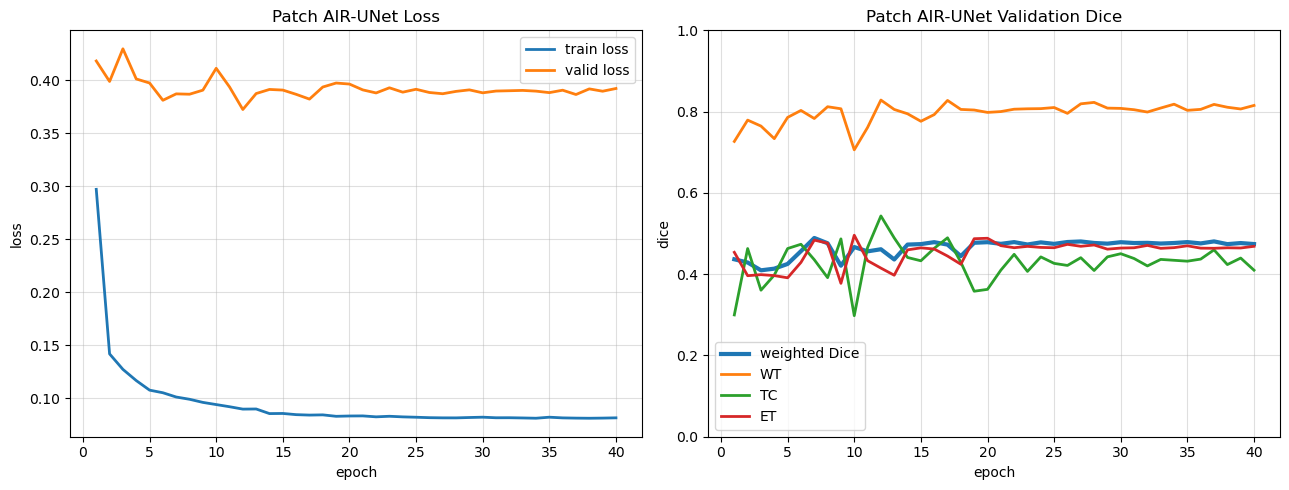

Saved Dice-by-split plot: /home/danishzaheer/Deep_learning_project/checkpoints/patch_air_unet_dice_by_split.png


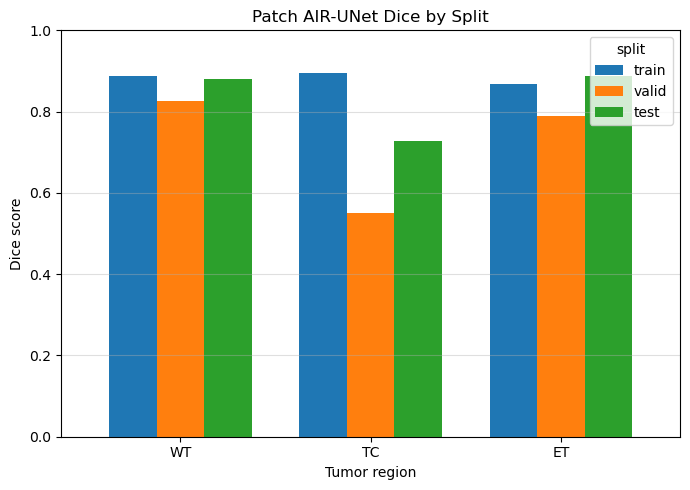

split,train,valid,test
region,,,
WT,0.888830,0.827038,0.879805
TC,0.894509,0.550569,0.727011
ET,0.867714,0.789852,0.887026


In [13]:
# Block 12: Visualize patch-model loss decrease, validation Dice curves, and Dice by split for report figures.
# Run this after Block 10 so final_metrics_df is already available.

history_source = 'current notebook memory'

if 'history_df' not in globals() or history_df.empty:
    if checkpoint_path.exists():
        checkpoint = torch.load(checkpoint_path, map_location='cpu')
        history_df = pd.DataFrame(checkpoint.get('history', []))
        history_source = str(checkpoint_path)
    else:
        raise FileNotFoundError('No history_df in memory and no latest checkpoint found.')

history_df = history_df.sort_values('epoch').reset_index(drop=True)
print('Loaded history from:', history_source)
print('Epochs available:', len(history_df))

best_history_row = history_df.loc[history_df['valid_weighted_dice'].idxmax()]
print('Best validation weighted Dice epoch:', int(best_history_row['epoch']))
print('Best validation weighted Dice:', round(float(best_history_row['valid_weighted_dice']), 4))

plt.figure(figsize=(13, 5))

plt.subplot(1, 2, 1)
plt.plot(history_df['epoch'], history_df['train_loss'], label='train loss', linewidth=2)
plt.plot(history_df['epoch'], history_df['valid_loss'], label='valid loss', linewidth=2)
plt.xlabel('epoch')
plt.ylabel('loss')
plt.title('Patch AIR-UNet Loss')
plt.grid(True, alpha=0.4)
plt.legend()

plt.subplot(1, 2, 2)
plt.plot(history_df['epoch'], history_df['valid_weighted_dice'], label='weighted Dice', linewidth=3)
plt.plot(history_df['epoch'], history_df['valid_WT_dice'], label='WT', linewidth=2)
plt.plot(history_df['epoch'], history_df['valid_TC_dice'], label='TC', linewidth=2)
plt.plot(history_df['epoch'], history_df['valid_ET_dice'], label='ET', linewidth=2)
plt.xlabel('epoch')
plt.ylabel('dice')
plt.title('Patch AIR-UNet Validation Dice')
plt.ylim(0, 1)
plt.grid(True, alpha=0.4)
plt.legend()

plt.tight_layout()
loss_dice_plot_path = CHECKPOINT_ROOT / 'patch_air_unet_loss_and_validation_dice.png'
plt.savefig(loss_dice_plot_path, dpi=300, bbox_inches='tight')
print('Saved loss/Dice plot:', loss_dice_plot_path)
plt.show()

if 'final_metrics_df' not in globals():
    raise NameError('Run Block 10 first so final_metrics_df is available for Dice-by-split plotting.')

bar_df = final_metrics_df.pivot(index='region', columns='split', values='dice').reindex(REGION_NAMES)
bar_df = bar_df[[split for split in ['train', 'valid', 'test'] if split in bar_df.columns]]

ax = bar_df.plot(kind='bar', figsize=(7, 5), width=0.75)
ax.set_title('Patch AIR-UNet Dice by Split')
ax.set_xlabel('Tumor region')
ax.set_ylabel('Dice score')
ax.set_ylim(0, 1)
ax.grid(axis='y', alpha=0.4)
plt.xticks(rotation=0)
plt.legend(title='split')
plt.tight_layout()

bar_plot_path = CHECKPOINT_ROOT / 'patch_air_unet_dice_by_split.png'
plt.savefig(bar_plot_path, dpi=300, bbox_inches='tight')
print('Saved Dice-by-split plot:', bar_plot_path)
plt.show()

display(bar_df)